# Bank Credit Card Churn Prediction
## Exploratory Data Analysis (EDA)

The goal of this notebook is to deeply explore the dataset, understand distributions,
identify patterns, and find the key factors that separate churned customers from existing ones.
These findings will directly guide my modeling decisions.

### Import Libraries

In [95]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.gridspec import GridSpec

### Load the Cleaned Dataset

In [96]:
df = pd.read_csv('BankChurners.csv')
df=df.iloc[:,:-2]
df['Churn']=(df['Attrition_Flag']=='Attrited Customer').astype(int)
print(f"Shape: {df.shape[0]} rows, {df.shape[1]} columns")
df.head()

Shape: 10127 rows, 22 columns


,CLIENTNUM,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,...,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio,Churn
0,768805383,Existing Customer,45,M,3,High School,Married,$60K - $80K,Blue,39,...,3,12691.0,777,11914.0,1.335,1144,42,1.625,0.061,0
1,818770008,Existing Customer,49,F,5,Graduate,Single,Less than $40K,Blue,44,...,2,8256.0,864,7392.0,1.541,1291,33,3.714,0.105,0
2,713982108,Existing Customer,51,M,3,Graduate,Married,$80K - $120K,Blue,36,...,0,3418.0,0,3418.0,2.594,1887,20,2.333,0.000,0
3,769911858,Existing Customer,40,F,4,High School,Unknown,Less than $40K,Blue,34,...,1,3313.0,2517,796.0,1.405,1171,20,2.333,0.760,0
4,709106358,Existing Customer,40,M,3,Uneducated,Married,$60K - $80K,Blue,21,...,0,4716.0,0,4716.0,2.175,816,28,2.500,0.000,0


### PART 1: Churn Distribution Analysis

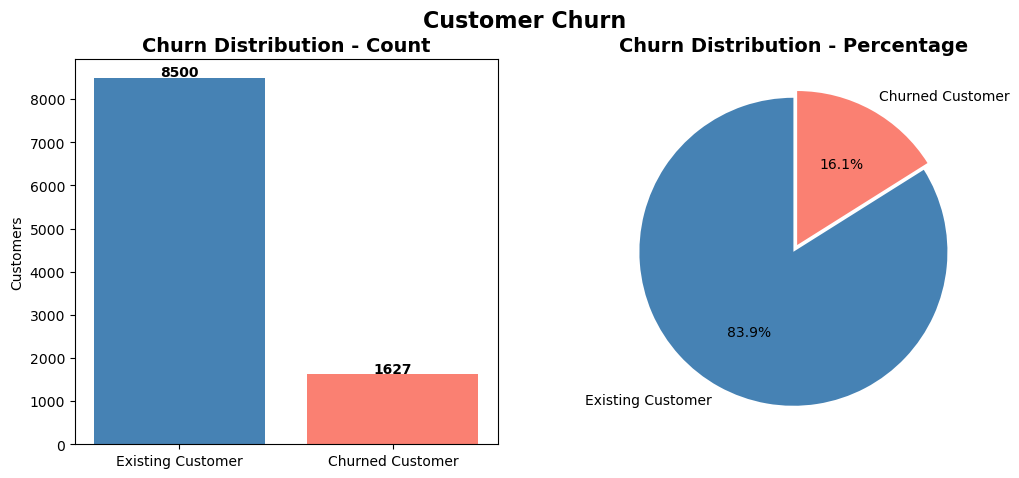

Existing Customers: 8500(83.9%)
Churned Customers:  1627(16.1%)
Class imbalance confirmed. I will use SMOTE during the modeling stage


In [97]:
fig, axes = plt.subplots(1,2,figsize=(12, 5))
churn_counts = df['Churn'].value_counts()
colors=['steelblue','salmon']
axes[0].bar(['Existing Customer','Churned Customer'],churn_counts.values,color=colors)
axes[0].set_title('Churn Distribution - Count',fontsize=14,fontweight='bold')
axes[0].set_ylabel('Customers')
for i, v in enumerate(churn_counts.values):
    axes[0].text(i, v+30, str(v), ha='center', fontweight='bold')

churn_pct = df['Churn'].value_counts()
axes[1].pie(churn_pct.values,labels=['Existing Customer', 'Churned Customer'],colors=colors, autopct='%1.1f%%', startangle=90, explode=(0, 0.05))
axes[1].set_title('Churn Distribution - Percentage', fontsize=14, fontweight='bold')

plt.suptitle('Customer Churn',fontsize=16,fontweight='bold')
plt.savefig('churn_distribution.png',dpi=150)
plt.show()
print(f"Existing Customers: {churn_counts[0]}({churn_counts[0]/len(df)*100:.1f}%)")
print(f"Churned Customers:  {churn_counts[1]}({churn_counts[1]/len(df)*100:.1f}%)")
print(f"Class imbalance confirmed. I will use SMOTE during the modeling stage")

### PART 2: Univariate Analysis

Here I examine each feature individually to understand its distribution.

#### 2.1 Categorical Features

C:\Users\MeriTorghvaidze\AppData\Local\Temp\ipykernel_2580\660654633.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=c,ax=axes[i], palette='Blues_r', order=order)
C:\Users\MeriTorghvaidze\AppData\Local\Temp\ipykernel_2580\660654633.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=c,ax=axes[i], palette='Blues_r', order=order)
C:\Users\MeriTorghvaidze\AppData\Local\Temp\ipykernel_2580\660654633.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=c,ax=axes[i], palette='Blues_r', order=order)
C:\User

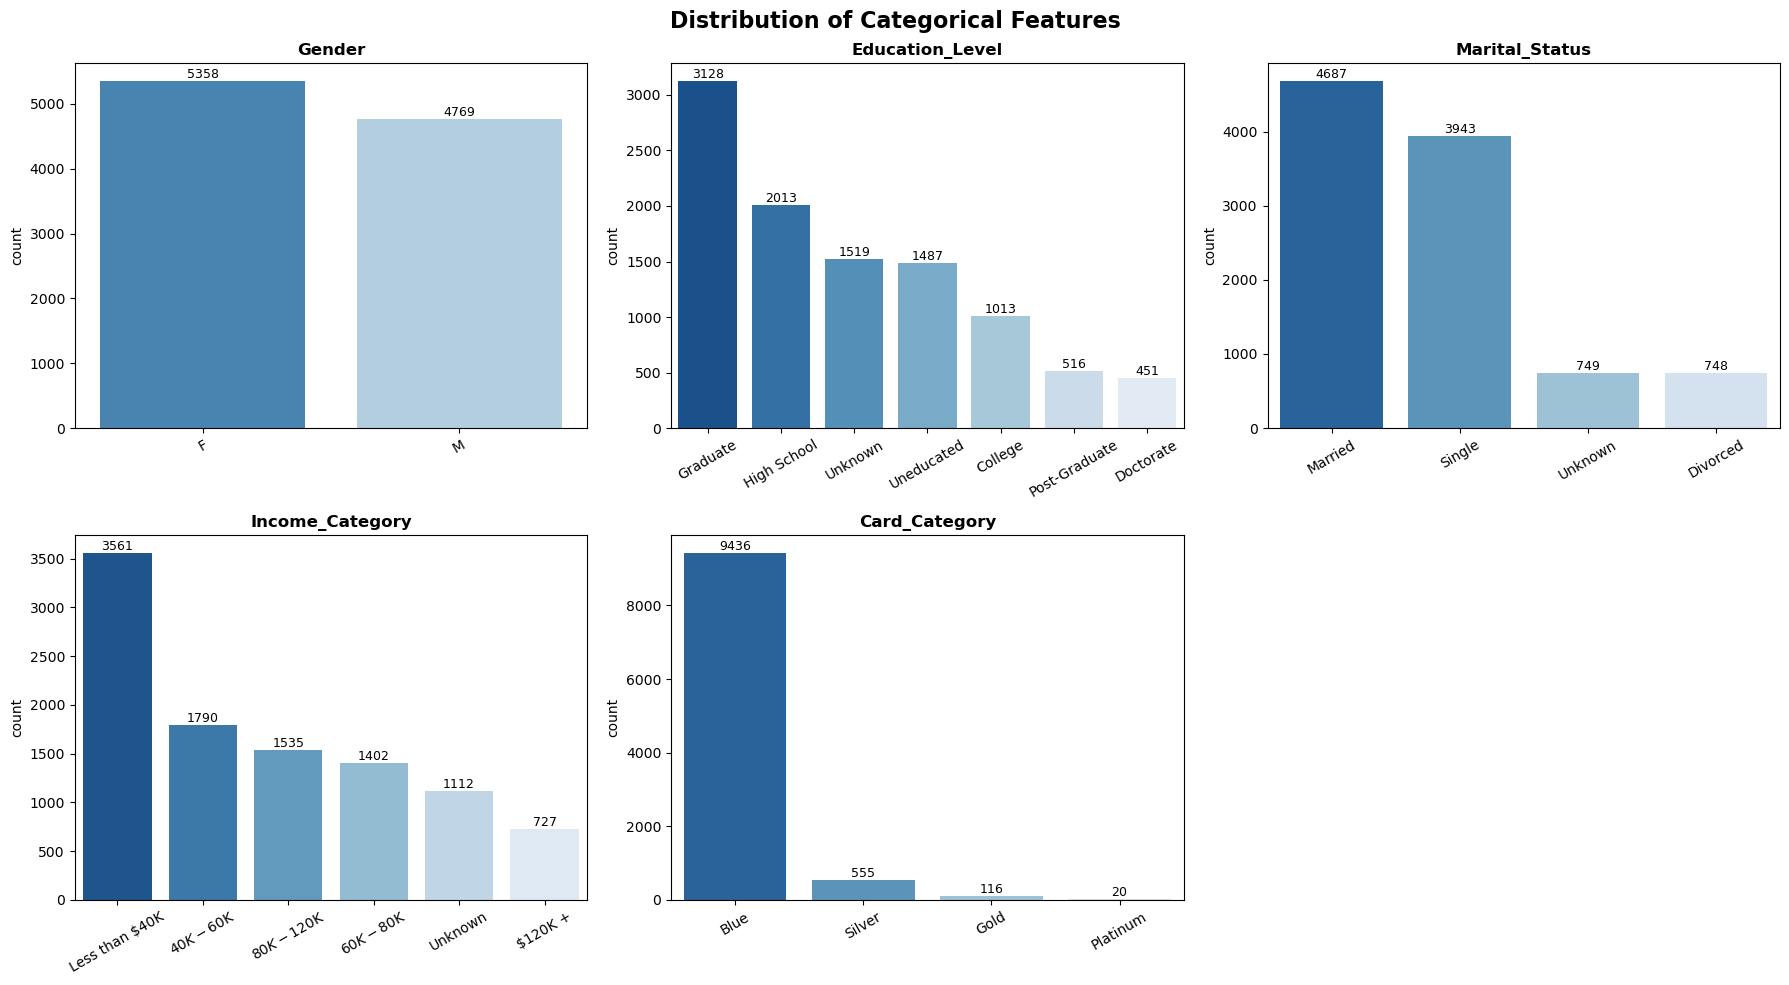

In [98]:
categorical_cols = ['Gender', 'Education_Level', 'Marital_Status', 'Income_Category', 'Card_Category']
fig,axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()
for i, c in enumerate(categorical_cols):
    order = df[c].value_counts().index
    sns.countplot(data=df, x=c,ax=axes[i], palette='Blues_r', order=order)
    axes[i].set_title(f'{c}',fontsize=12, fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x',rotation=30)
    for p in axes[i].patches:
        axes[i].annotate(f'{int(p.get_height())}', (p.get_x()+p.get_width()/2, p.get_height()), ha='center', va='bottom', fontsize=9)

axes[5].set_visible(False)
plt.suptitle('Distribution of Categorical Features',fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('categorical_distributions.png',dpi=150)
plt.show()

#### 2.2 Numerical Features

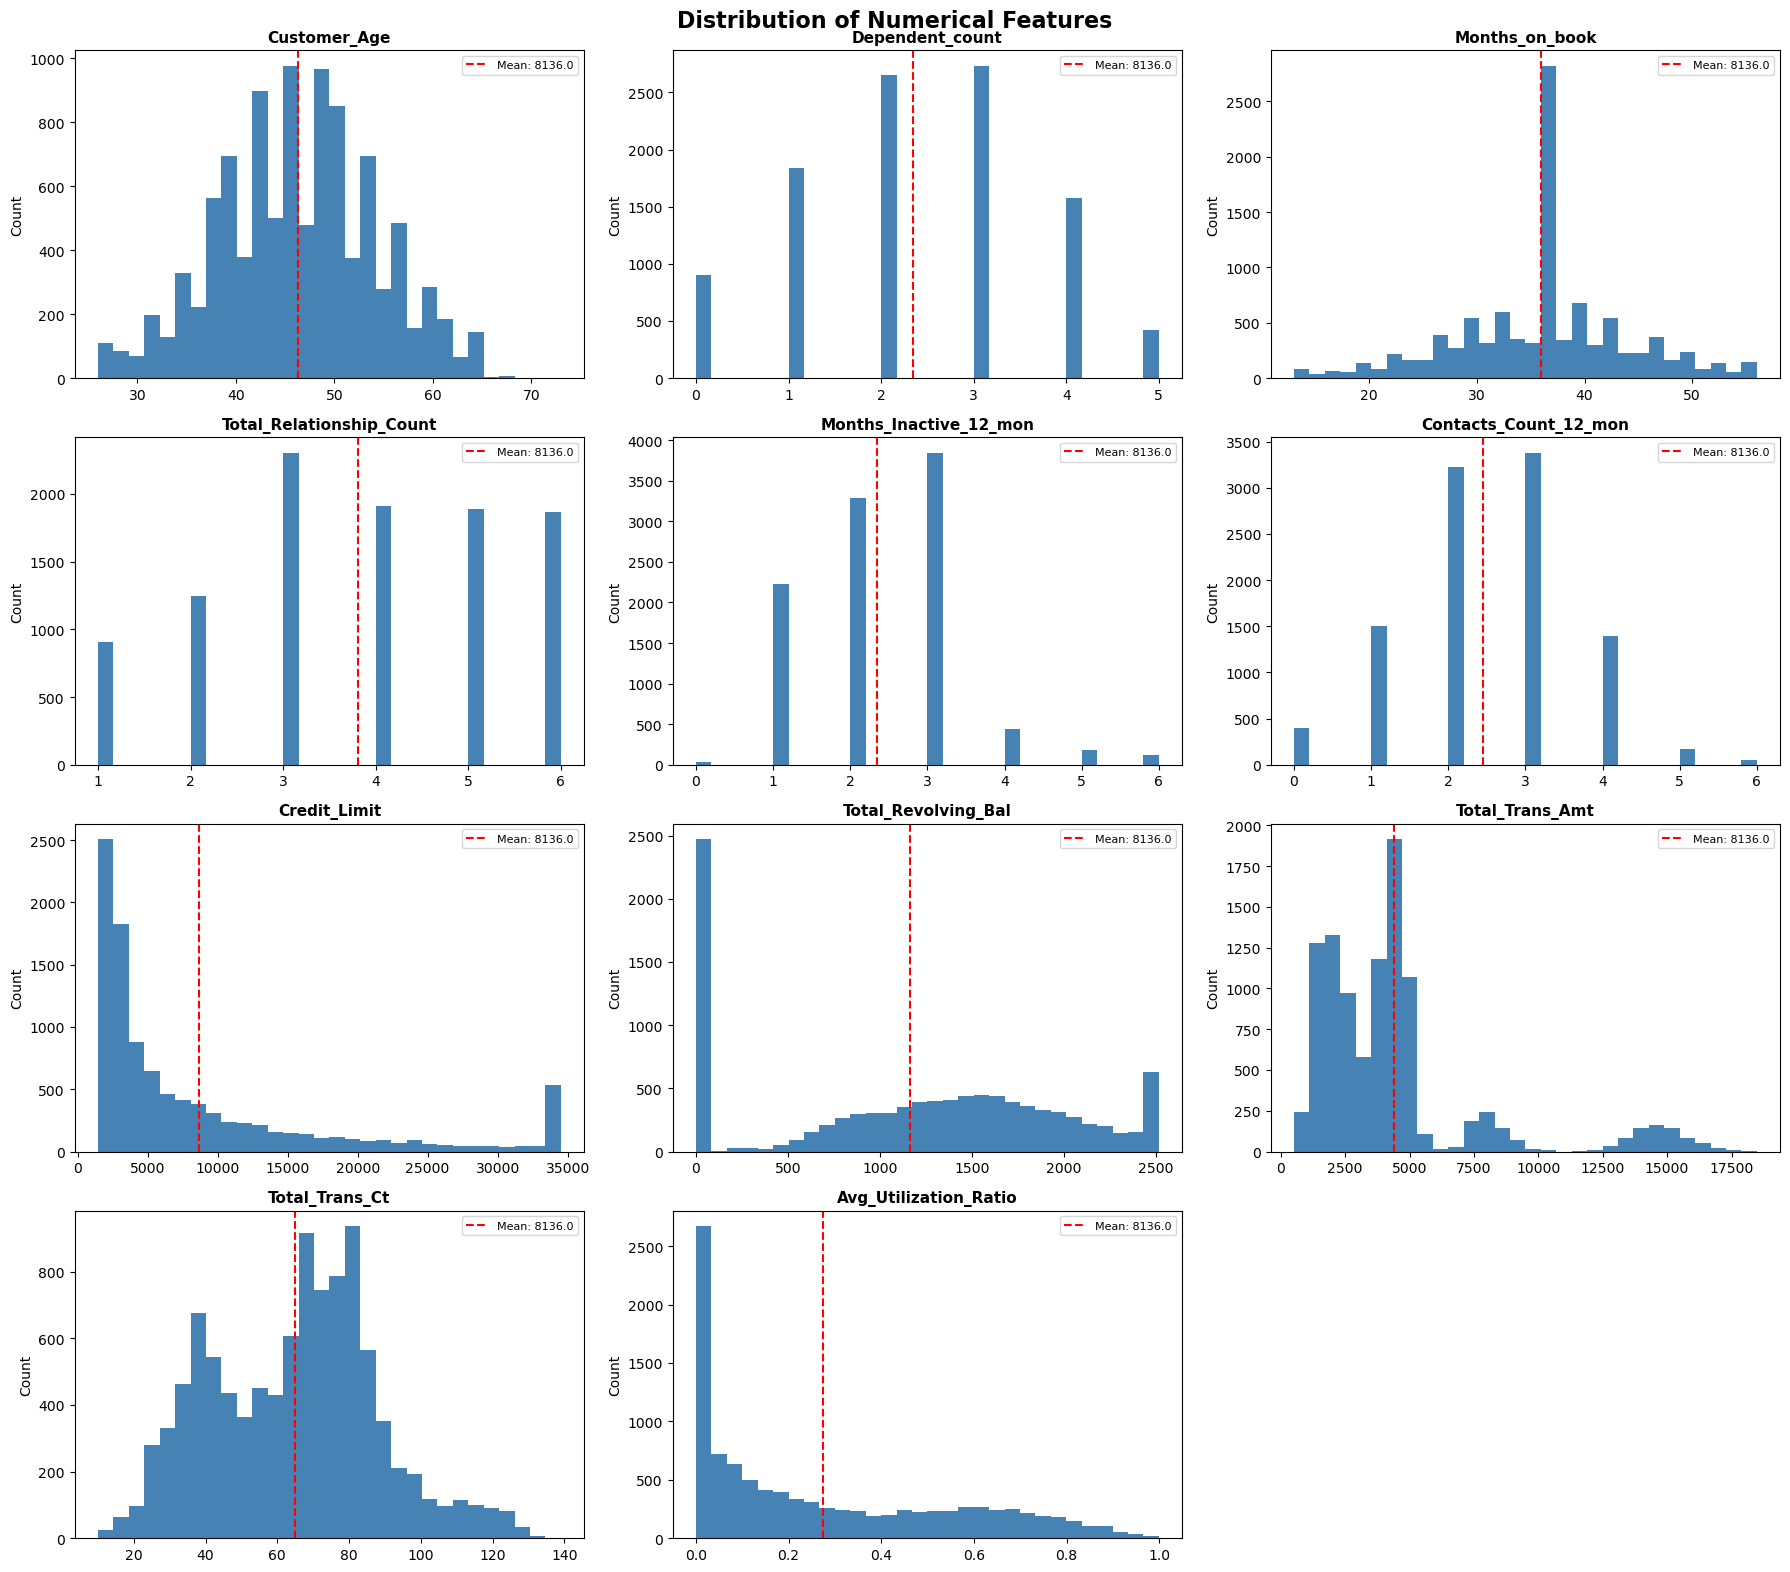

In [99]:
numerical_cols = ['Customer_Age', 'Dependent_count', 'Months_on_book','Total_Relationship_Count', 'Months_Inactive_12_mon',
                  'Contacts_Count_12_mon', 'Credit_Limit', 'Total_Revolving_Bal', 'Total_Trans_Amt', 
                  'Total_Trans_Ct', 'Avg_Utilization_Ratio']
fig,axes = plt.subplots(4,3,figsize=(18,16))
axes= axes.flatten()
for i, c in enumerate(numerical_cols):
    axes[i].hist(df[c],bins=30, color='steelblue', linewidth=0.5)
    axes[i].set_title(f'{c}', fontsize=11,fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Count')
    mean=df[c].mean()
    axes[i].axvline(mean,color='red', linestyle='--',label=f'Mean: {mean_val:.1f}')
    axes[i].legend(fontsize = 8)
axes[11].set_visible(False)

plt.suptitle('Distribution of Numerical Features', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('numerical_distributions.png', dpi=150)
plt.show()

### PART 3: Bivariate Analysis

Now I compare churned vs existing customers across all features.
it reveals which features are the strongest predictors of churn.

#### 3.1 Categorical Features vs Churn

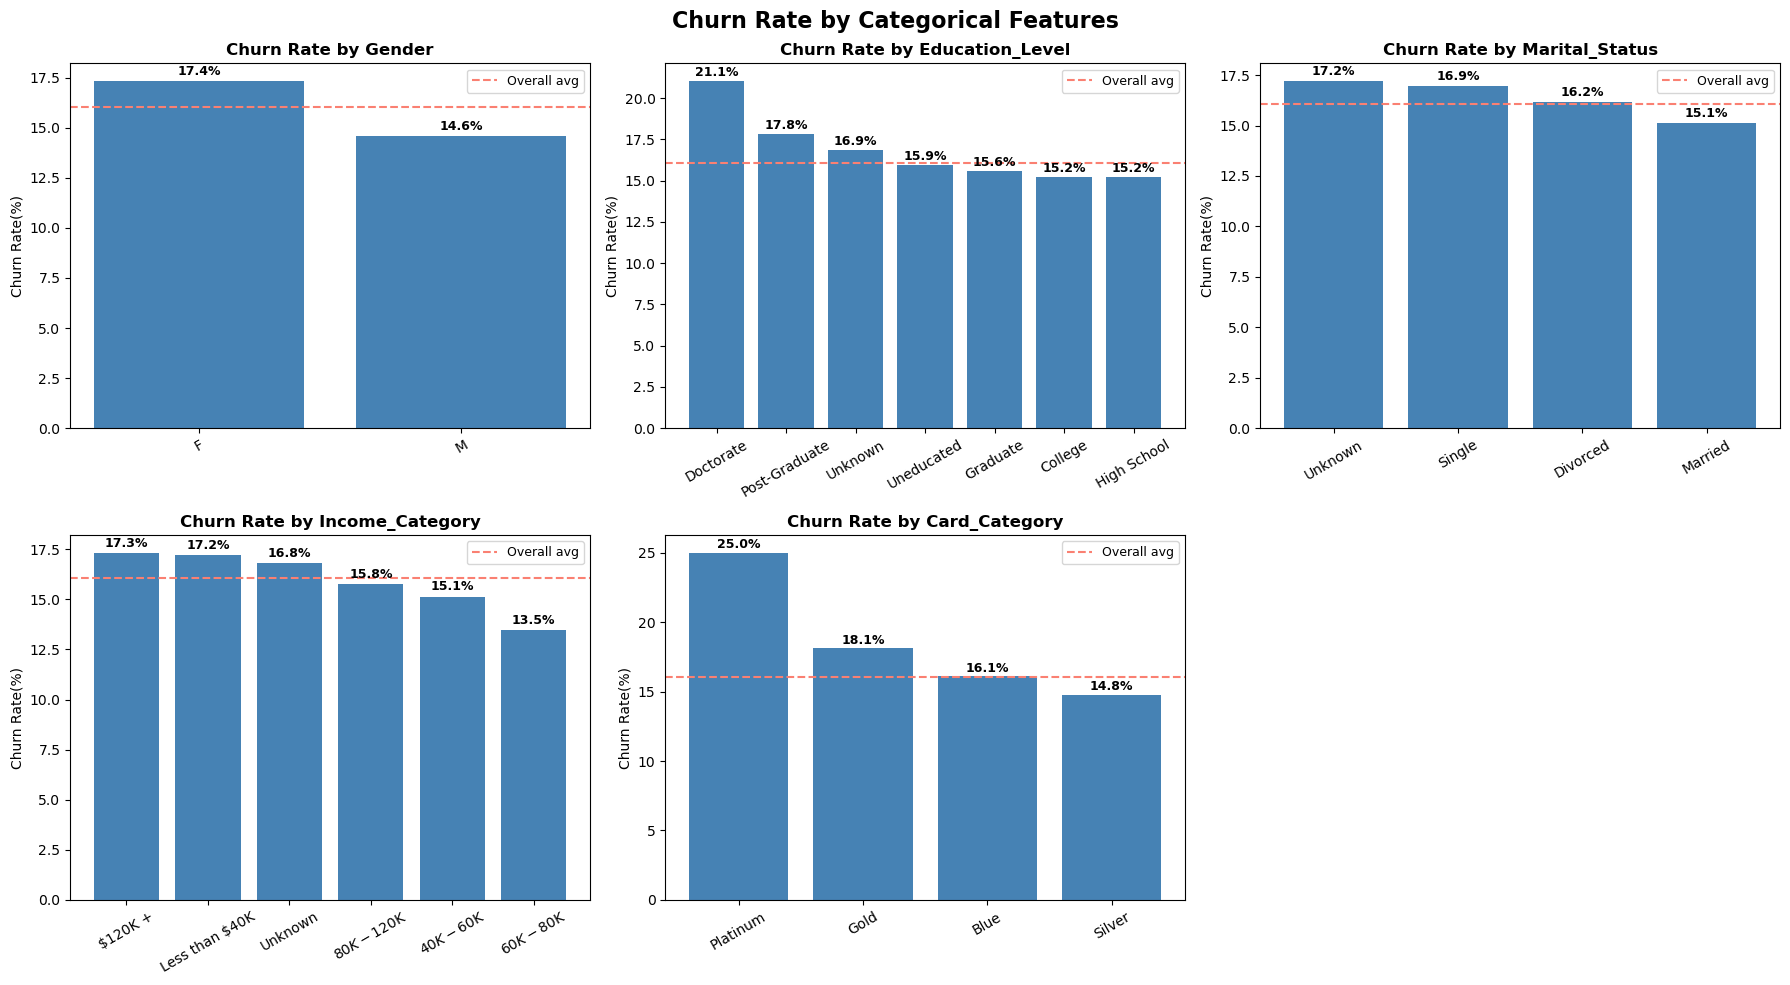

In [100]:
fig,axes =plt.subplots(2,3,figsize=(18,10))
axes = axes.flatten()

for i, c in enumerate(categorical_cols):
    churn_rate =df.groupby(c)['Churn'].mean()*100
    churn_rate =churn_rate.sort_values(ascending=False)
    bars =axes[i].bar(churn_rate.index, churn_rate.values, color='steelblue')
    axes[i].set_title(f'Churn Rate by {c}',fontsize=12, fontweight='bold')
    axes[i].set_ylabel('Churn Rate(%)')
    axes[i].tick_params(axis='x',rotation=30)
    axes[i].axhline(y=df['Churn'].mean()*100, color='salmon', linestyle='--', label='Overall avg')
    axes[i].legend(fontsize = 9)
    for bar, val in zip(bars, churn_rate.values):
        axes[i].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3, f'{val:.1f}%',ha='center', fontsize=9, fontweight='bold')
axes[5].set_visible(False)

plt.suptitle('Churn Rate by Categorical Features', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('categorical_churn_rates.png', dpi=150)
plt.show()

#### 3.2 Numerical Features vs Churn

I focus on key numerical features and compare
their distributions between churned and existing customers.

C:\Users\MeriTorghvaidze\AppData\Local\Temp\ipykernel_2580\3754050710.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Attrition_Flag', y=c, ax=axes[i],palette=['steelblue','salmon'])
C:\Users\MeriTorghvaidze\AppData\Local\Temp\ipykernel_2580\3754050710.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Attrition_Flag', y=c, ax=axes[i],palette=['steelblue','salmon'])
C:\Users\MeriTorghvaidze\AppData\Local\Temp\ipykernel_2580\3754050710.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Attrition_Flag'

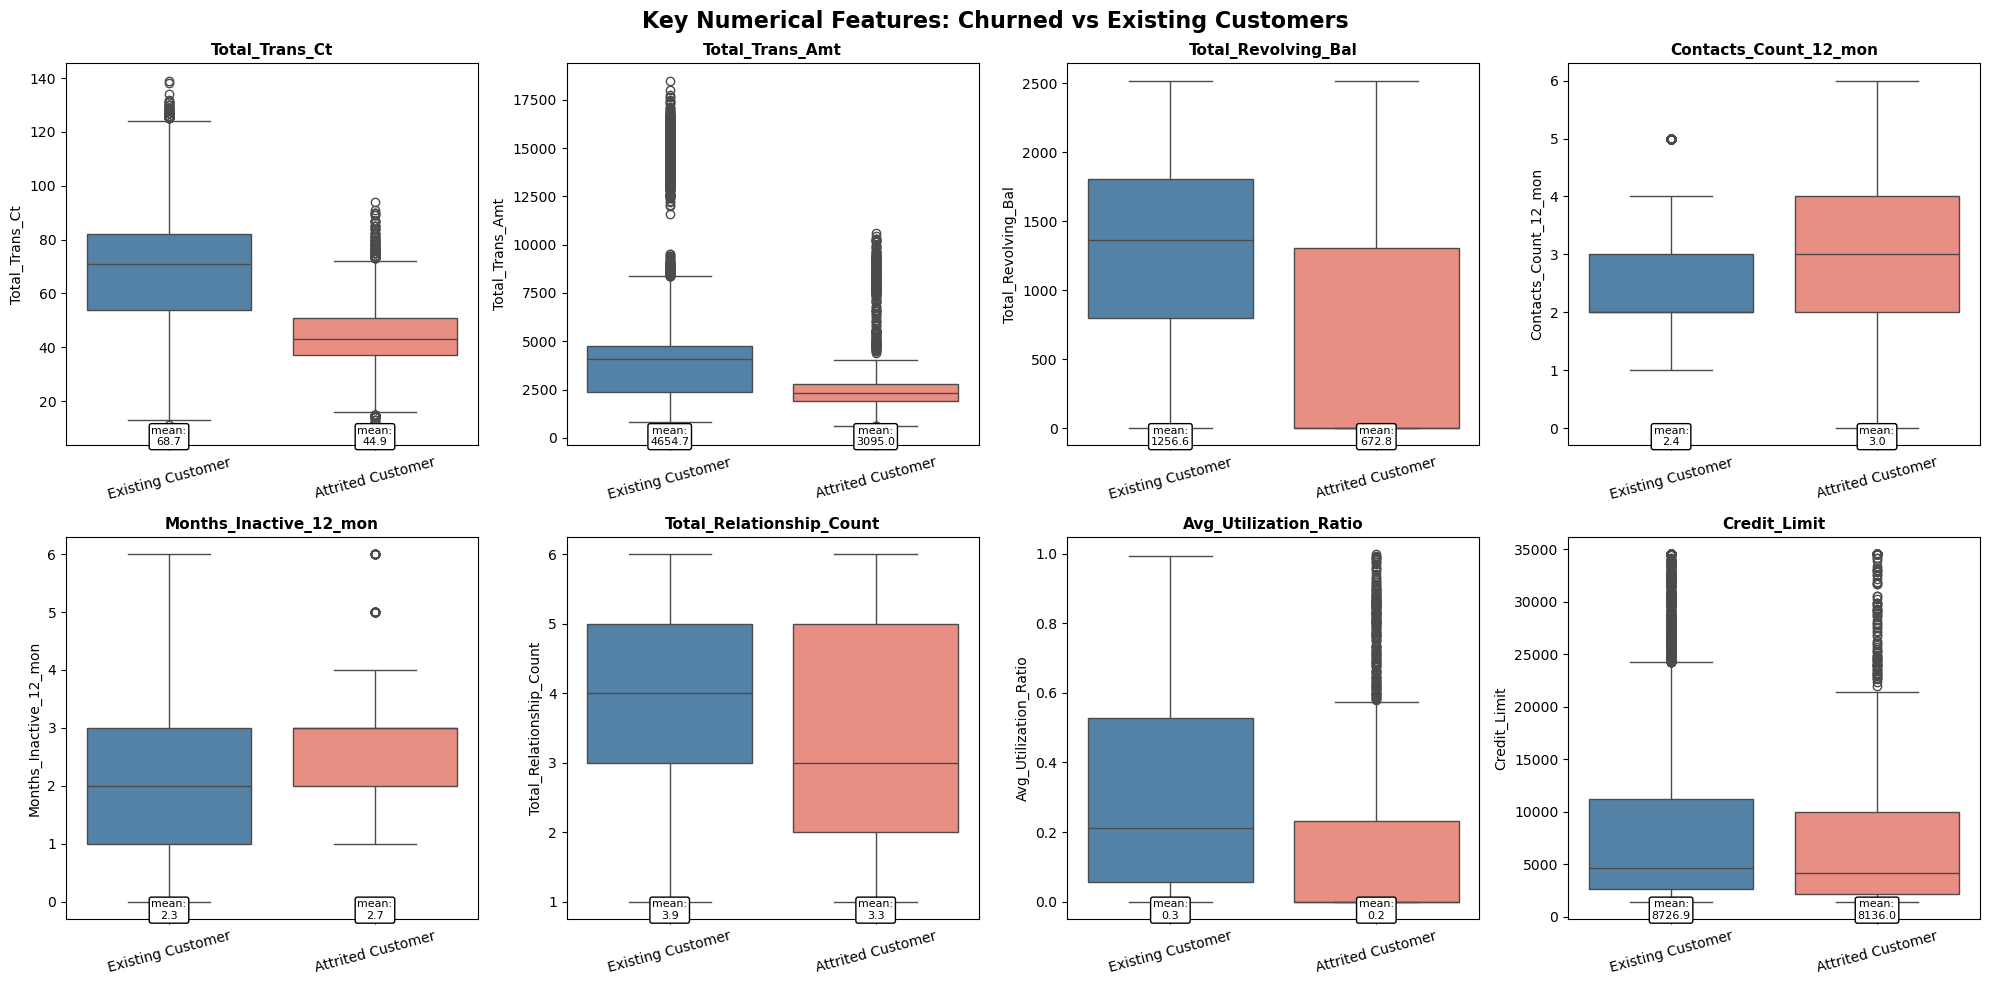

In [101]:
key_features = ['Total_Trans_Ct', 'Total_Trans_Amt', 'Total_Revolving_Bal','Contacts_Count_12_mon', 
                'Months_Inactive_12_mon', 'Total_Relationship_Count', 'Avg_Utilization_Ratio', 'Credit_Limit']
fig,axes = plt.subplots(2,4,figsize=(20,10))
axes = axes.flatten()

for i, c in enumerate(key_features):
    sns.boxplot(data=df, x='Attrition_Flag', y=c, ax=axes[i],palette=['steelblue','salmon'])
    axes[i].set_title(f'{c}', fontsize=11, fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x',rotation=15)
    for j, g in enumerate(['Existing Customer', 'Attrited Customer']):
        mean= df[df['Attrition_Flag']==g][c].mean()
        axes[i].text(j, axes[i].get_ylim()[0], f'mean:\n{mean:.1f}', ha='center', fontsize=8, color='black',
                    bbox=dict(boxstyle='round,pad=0.2', facecolor='white'))

plt.suptitle('Key Numerical Features: Churned vs Existing Customers', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('key_features_boxplots.png', dpi=150)
plt.show()